# Hybrid ALNS — Hyperparameter Tuning

**Objective:** `composite = 0.9 × mean_relative_gap + 0.1 × mean_normalized_time`

See `tuning_approach.ipynb` for full methodology.



In [1]:
from __future__ import annotations

import json
import warnings
from pathlib import Path

import numpy as np
import optuna
from optuna.importance import get_param_importances
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from tuning_config import (
    PIPELINE_SUMMARY_FILENAME,
    BASELINE_FILENAME,
    STAGE1_RANGES,
    BEST_EVAL_FILENAME,
    DEFAULT_OUTPUT_DIR,
    ISOLATION_MERGED_FILENAME,
    ISOLATION_STEP_TEMPLATE,
    STAGE1_STUDY_NAME,
    STAGE2_STUDY_NAME,
    STUDY_FILENAME_TEMPLATE,
)

warnings.filterwarnings("ignore", category=DeprecationWarning)

plt.rcParams.update(
    {
        "figure.dpi": 120,
        "figure.facecolor": "white",
        "font.size": 11,
        "axes.titlesize": 13,
        "axes.labelsize": 11,
    }
)

from collections import defaultdict






In [2]:
OUTPUT_DIR = Path(DEFAULT_OUTPUT_DIR)


---
## 1. Parameter Taxonomy



In [3]:
from tuning_config import DEFAULT_PARAMS, STRUCTURAL_DEFAULTS

In [4]:
import pandas as pd

tunable_rows = [
    (
        "initial_temperature",
        "1.4427",
        "(0.5, 5.0) log",
        "Starting SA temperature; controls early acceptance of worse solutions",
    ),
    (
        "alpha_cool",
        "0.9995",
        "(0.998, 0.9999)",
        "Cooling factor per iteration; slower cooling = more exploration",
    ),
    (
        "k_min_frac",
        "0.05",
        "(0.01, 0.20)",
        "Minimum destruction radius as fraction of item count",
    ),
    (
        "k_max_frac",
        "0.25",
        "(0.10, 0.40)",
        "Maximum destruction radius; grows adaptively with stagnation",
    ),
    (
        "bandit_alpha",
        "0.3",
        "(0.05, 1.0) log",
        "LinUCB exploration bonus; higher = more exploration between arms",
    ),
    (
        "warmup_calls",
        "300",
        "(50, 600)",
        "Thompson Sampling warm-up iterations before switching to LinUCB",
    ),
    (
        "no_improve_frac",
        "0.05",
        "(0.01, 0.20)",
        "Stagnation budget as fraction of max_iterations; triggers hard restart",
    ),
    (
        "reheat_soft_mult",
        "0.35",
        "(0.10, 0.90)",
        "Temperature multiplier for soft reheats (periodic mild rewarm)",
    ),
    (
        "reheat_hard_mult",
        "0.20",
        "(0.05, 0.80)",
        "Temperature multiplier for hard restarts (return to best + reheat)",
    ),
]

structural_rows = [
    (
        "min_no_improve_limit",
        "250",
        "Safety floor; real lever is `no_improve_frac × max_iter`",
    ),
    ("temp_precision_floor", "1e-12", "Division guard for T/T0 context feature"),
    (
        "reheat_check_interval_divisor",
        "4.0",
        "Tied to `no_improve_frac`; controls soft-reheat frequency",
    ),
    ("reheat_check_min_interval", "50", "Prevents excessive reheats on short runs"),
    ("hard_restart_min_limit", "100", "Prevents restart thrashing after shrinkage"),
    (
        "patience_shrink_factor",
        "2/3",
        "Shrink factor for no_improve_limit on hard restart; changed from 0.5",
    ),
]

df_tunable = pd.DataFrame(
    tunable_rows, columns=["Parameter", "Default", "Stage-1 Range", "Role"]
)
df_structural = pd.DataFrame(
    structural_rows, columns=["Parameter", "Default", "Why Held Fixed"]
)

display(
    df_tunable.style.set_caption("Tunable Parameters (9)").set_table_styles(
        [
            {
                "selector": "caption",
                "props": "font-size: 1.2em; font-weight: bold; margin-bottom: 6px;",
            },
            {"selector": "th", "props": "text-align: left;"},
        ]
    )
)
display(
    df_structural.style.set_caption(
        "Structural Parameters (6 — held fixed)"
    ).set_table_styles(
        [
            {
                "selector": "caption",
                "props": "font-size: 1.2em; font-weight: bold; margin-bottom: 6px;",
            },
            {"selector": "th", "props": "text-align: left;"},
        ]
    )
)


,Parameter,Default,Stage-1 Range,Role
0,initial_temperature,1.4427,"(0.5, 5.0) log",Starting SA temperature; controls early acceptance of worse solutions
1,alpha_cool,0.9995,"(0.998, 0.9999)",Cooling factor per iteration; slower cooling = more exploration
2,k_min_frac,0.05,"(0.01, 0.20)",Minimum destruction radius as fraction of item count
3,k_max_frac,0.25,"(0.10, 0.40)",Maximum destruction radius; grows adaptively with stagnation
4,bandit_alpha,0.3,"(0.05, 1.0) log",LinUCB exploration bonus; higher = more exploration between arms
5,warmup_calls,300,"(50, 600)",Thompson Sampling warm-up iterations before switching to LinUCB
6,no_improve_frac,0.05,"(0.01, 0.20)",Stagnation budget as fraction of max_iterations; triggers hard restart
7,reheat_soft_mult,0.35,"(0.10, 0.90)",Temperature multiplier for soft reheats (periodic mild rewarm)
8,reheat_hard_mult,0.20,"(0.05, 0.80)",Temperature multiplier for hard restarts (return to best + reheat)


,Parameter,Default,Why Held Fixed
0,min_no_improve_limit,250,Safety floor; real lever is `no_improve_frac × max_iter`
1,temp_precision_floor,1e-12,Division guard for T/T0 context feature
2,reheat_check_interval_divisor,4.0,Tied to `no_improve_frac`; controls soft-reheat frequency
3,reheat_check_min_interval,50,Prevents excessive reheats on short runs
4,hard_restart_min_limit,100,Prevents restart thrashing after shrinkage
5,patience_shrink_factor,2/3,Shrink factor for no_improve_limit on hard restart; changed from 0.5


---
## 2. Results



---


In [5]:
def load_json(path: Path) -> dict | None:
    if not path.exists():
        print(f"[MISSING] {path.name} — run the tuning script first.")
        return None
    with open(path) as f:
        return json.load(f)


baseline_raw = load_json(OUTPUT_DIR / BASELINE_FILENAME)
iso_sa_raw = load_json(OUTPUT_DIR / ISOLATION_STEP_TEMPLATE.format(step_key="step1_sa_thermal"))
iso_dest_raw = load_json(OUTPUT_DIR / ISOLATION_STEP_TEMPLATE.format(step_key="step2_destruction"))
iso_bandit_raw = load_json(OUTPUT_DIR / ISOLATION_STEP_TEMPLATE.format(step_key="step3_bandit"))
iso_merged_raw = load_json(OUTPUT_DIR / ISOLATION_MERGED_FILENAME)
stage1_raw = load_json(OUTPUT_DIR / STUDY_FILENAME_TEMPLATE.format(name=STAGE1_STUDY_NAME))
stage2_raw = load_json(OUTPUT_DIR / STUDY_FILENAME_TEMPLATE.format(name=STAGE2_STUDY_NAME))
best_raw = load_json(OUTPUT_DIR / BEST_EVAL_FILENAME)
pipeline_raw = load_json(OUTPUT_DIR / PIPELINE_SUMMARY_FILENAME)

data_loaded = all(
    x is not None for x in [baseline_raw, stage1_raw, stage2_raw, best_raw]
)
if data_loaded:
    print("All result files loaded successfully.")
else:
    print("Run `python tune_with_optuna.py` to generate results.")




All result files loaded successfully.


---
## 3. Stage 1 — Coarse Search



In [6]:
if stage1_raw:
    print(f"Trials completed:  {stage1_raw['n_trials']}")
    print(f"Best composite objective: {stage1_raw['best_value']:.4f}")
    best_trial_s1 = min(stage1_raw["trials"], key=lambda t: t["value"])
    s1_mean_gap = best_trial_s1.get("metrics", {}).get("mean_relative_gap", stage1_raw["best_value"])

    print(f"Best parameters:")
    for k, v in stage1_raw["best_params"].items():
        print(f"    {k:25s} = {v}")

    def _all_trial_ranges(trials, margin=0.15):
        ranges = {}
        for pk in trials[0]["params"]:
            vals = [t["params"][pk] for t in trials]
            lo, hi = min(vals), max(vals)
            span = max(hi - lo, abs(lo) * 0.1)
            is_int = all(isinstance(v, int) for v in vals)
            if is_int:
                ranges[pk] = optuna.distributions.IntDistribution(
                    int(lo - span * margin), int(hi + span * margin + 1)
                )
            else:
                ranges[pk] = optuna.distributions.FloatDistribution(
                    lo - span * margin, hi + span * margin
                )
        return ranges

    stage1_study = optuna.create_study(
        direction="minimize", study_name=STAGE1_STUDY_NAME
    )
    dists = _all_trial_ranges(stage1_raw["trials"])
    for t in stage1_raw["trials"]:
        stage1_study.add_trial(
            optuna.trial.create_trial(
                params=t["params"],
                values=[t["value"]],
                distributions=dists,
                state=optuna.trial.TrialState.COMPLETE,
            )
        )


[I 2026-05-30 17:51:38,717] A new study created in memory with name: alns_stage1_coarse


Trials completed:  48
Best composite objective: 0.0526
Best parameters:
    initial_temperature       = 1.8
    alpha_cool                = 0.9992
    reheat_soft_mult          = 0.42
    reheat_hard_mult          = 0.18
    k_min_frac                = 0.04
    k_max_frac                = 0.22
    no_improve_frac           = 0.06
    bandit_alpha              = 0.45
    warmup_calls              = 250


### 3.1 Convergence


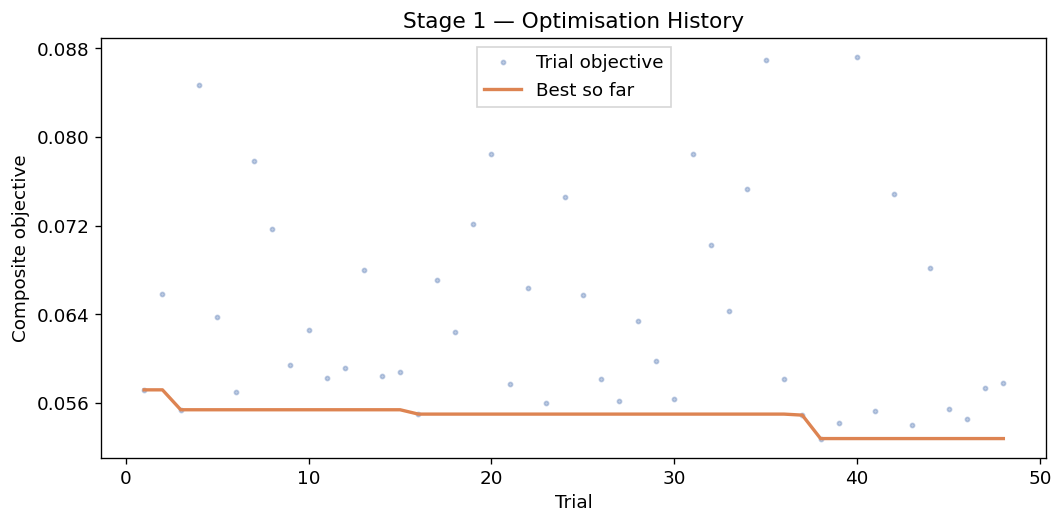

In [7]:
if stage1_raw:
    values = [t["value"] for t in stage1_raw["trials"]]
    best_so_far = np.minimum.accumulate(values)

    fig, ax = plt.subplots(figsize=(9, 4.5))
    ax.plot(range(1, len(values) + 1), values, "o", color="#4C72B0",
            markersize=2.5, alpha=0.35, label="Trial objective")
    ax.plot(range(1, len(values) + 1), best_so_far, "-", color="#DD8452",
            linewidth=2, label="Best so far")
    ax.set_xlabel("Trial")
    ax.set_ylabel("Composite objective")
    ax.set_title("Stage 1 — Optimisation History")
    ax.legend(frameon=True, fancybox=False)
    ax.yaxis.set_major_locator(mticker.MaxNLocator(6))
    fig.tight_layout()
    plt.show()


### 3.2 Parameter Importance


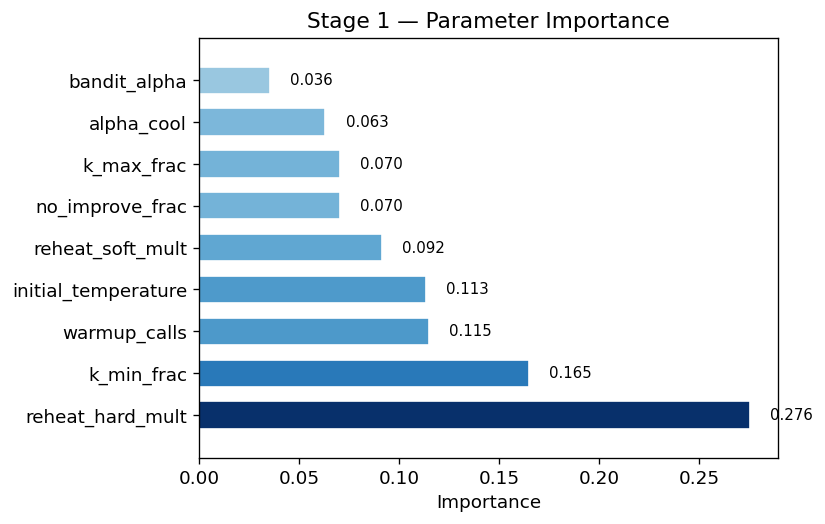

In [8]:
if stage1_raw:
    importances = get_param_importances(stage1_study)
    if not importances:
        print("Parameter importance: not available (insufficient trial variation).")
    else:
        params = list(importances.keys())
        scores = list(importances.values())
        score_arr = np.array(scores)
        colors = plt.cm.Blues(0.3 + 0.7 * (score_arr / score_arr.max()))

        fig, ax = plt.subplots(figsize=(7, 4.5))
        bars = ax.barh(params, scores, color=colors, edgecolor="white", height=0.65)
        for bar, s in zip(bars, scores):
            ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2,
                    f"{s:.3f}", va="center", fontsize=9)
        ax.set_xlabel("Importance")
        ax.set_title("Stage 1 — Parameter Importance")
        ax.margins(y=0.08)
        fig.tight_layout()
        plt.show()


### 3.3 Parameter Scatter


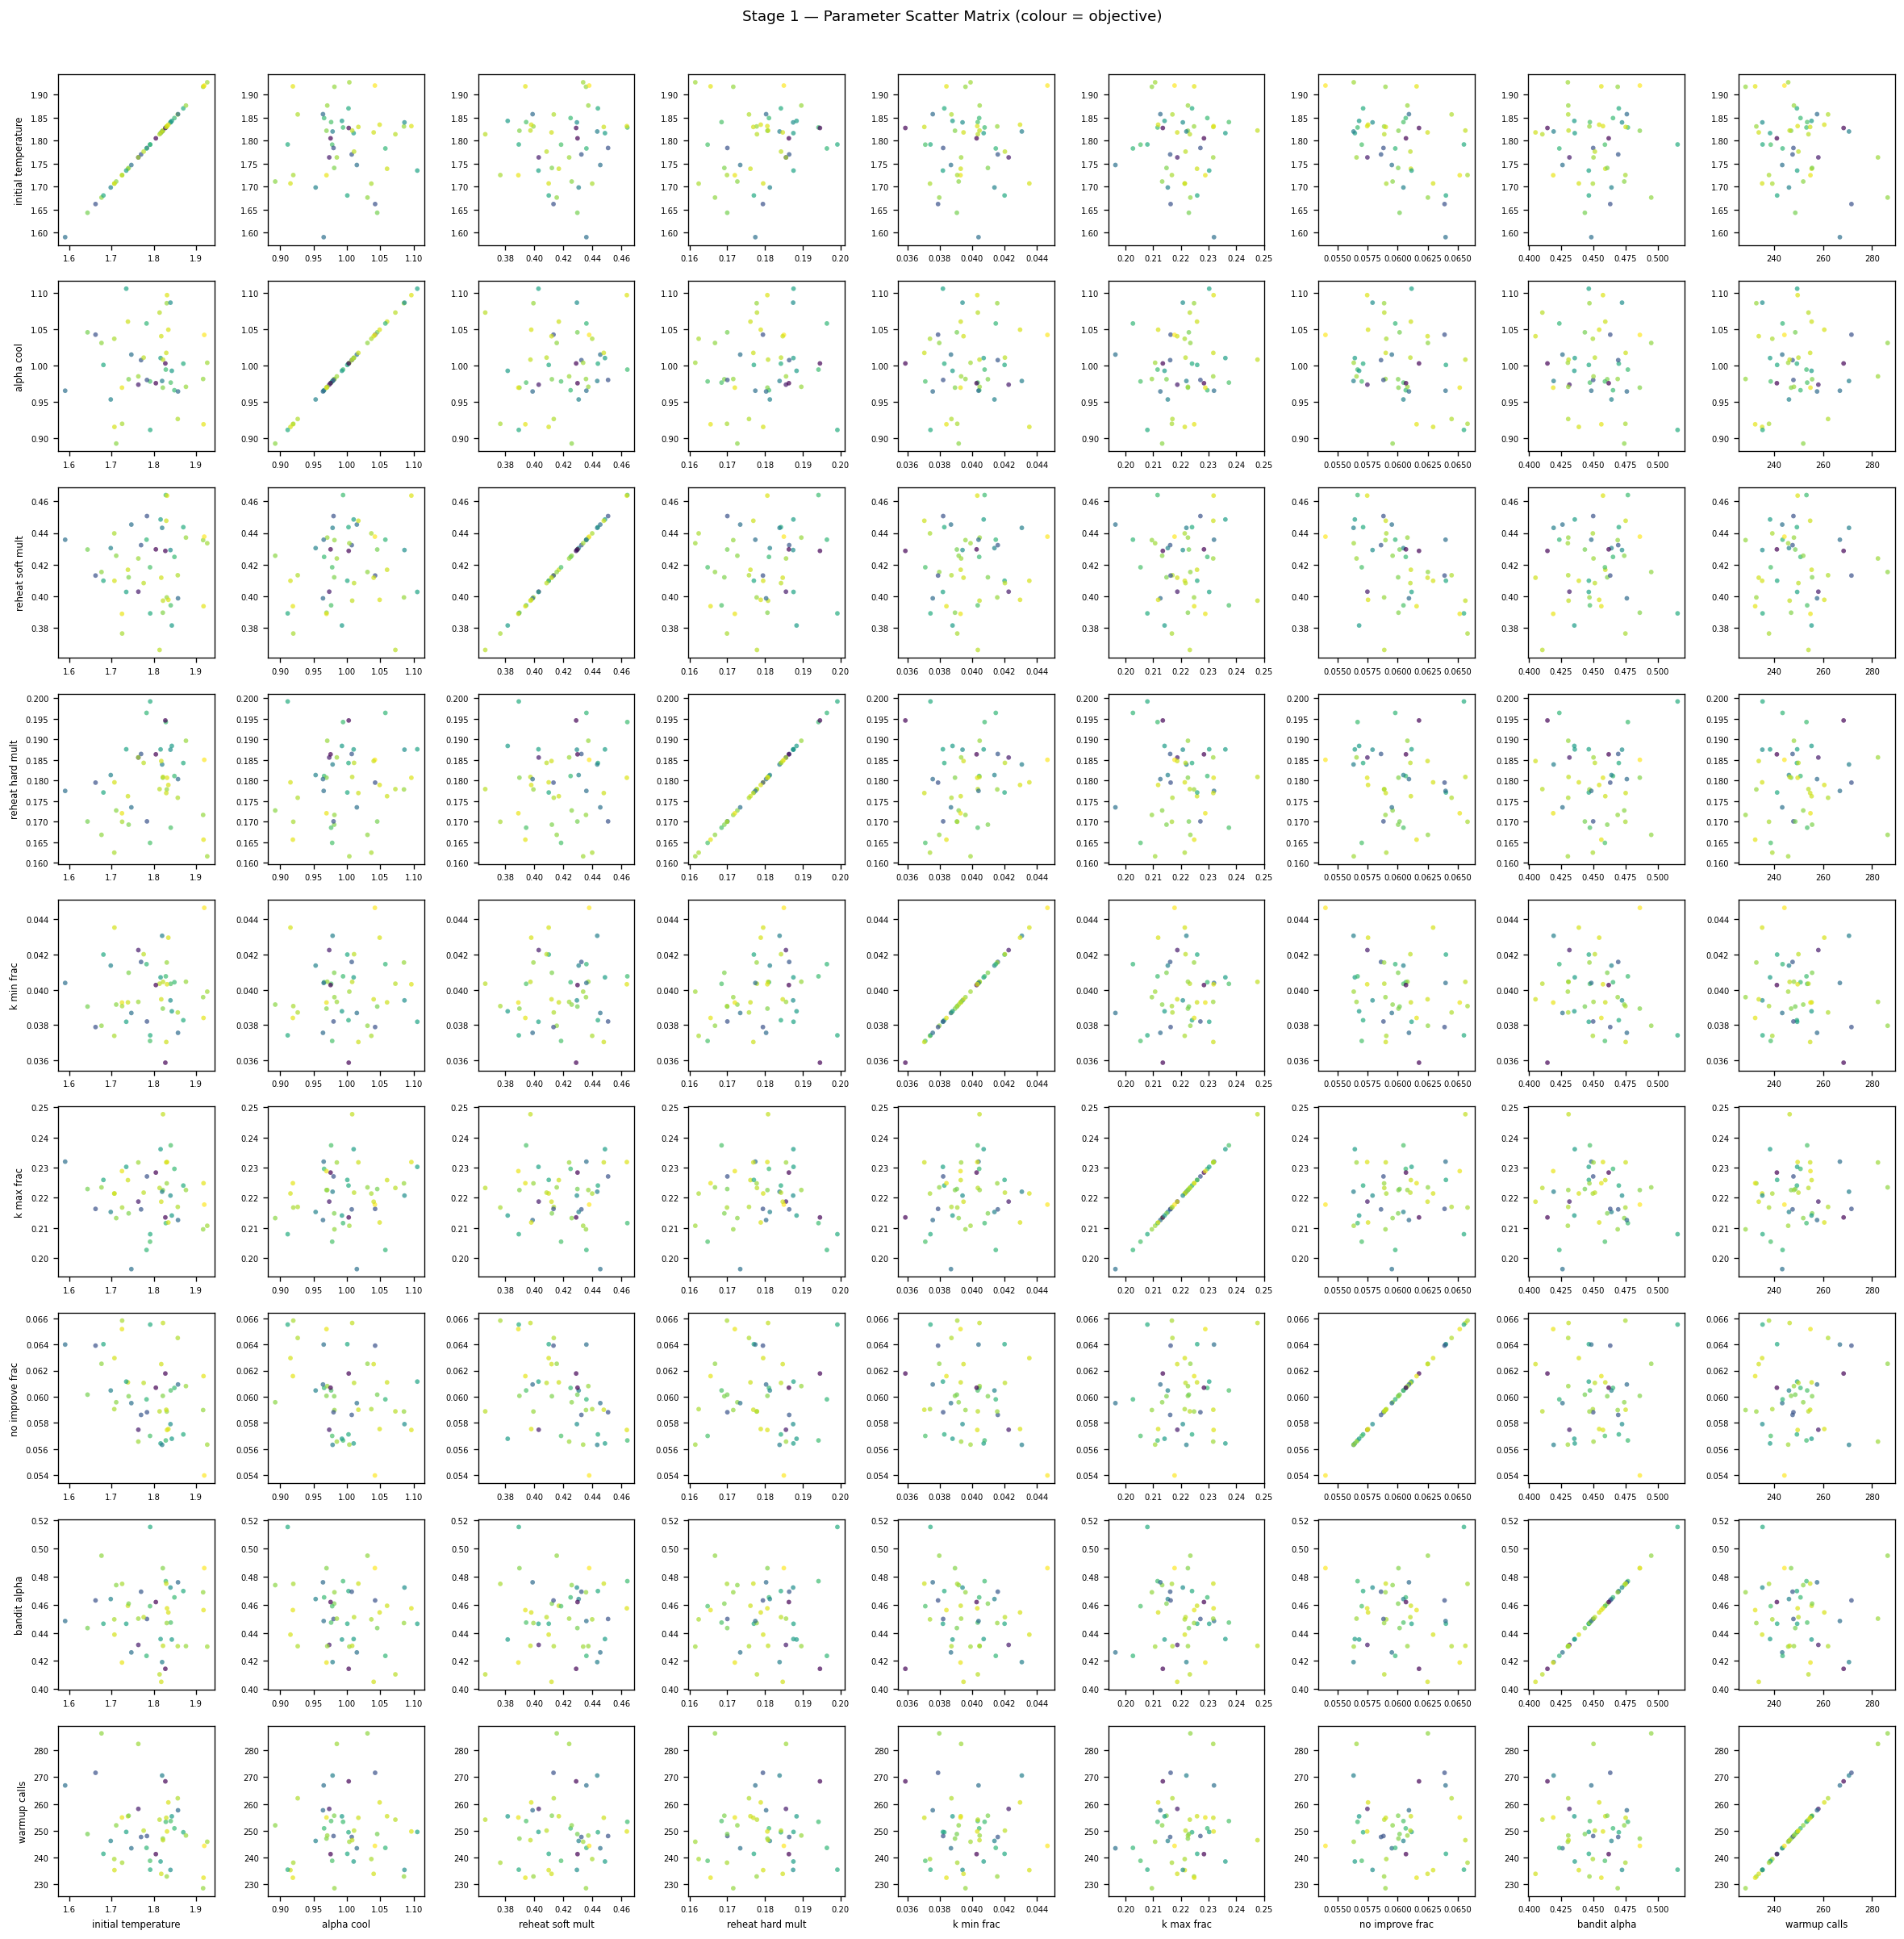

In [9]:
if stage1_raw and len(stage1_raw["trials"]) >= 5:
    param_keys = list(stage1_raw["trials"][0]["params"].keys())
    n = len(param_keys)
    fig, axes = plt.subplots(n, n, figsize=(2.2 * n, 2.2 * n))

    for i, pi in enumerate(param_keys):
        for j, pj in enumerate(param_keys):
            ax = axes[i, j]
            vals_i = [t["params"][pi] for t in stage1_raw["trials"]]
            vals_j = [t["params"][pj] for t in stage1_raw["trials"]]
            obj = [t["value"] for t in stage1_raw["trials"]]
            sc = ax.scatter(vals_j, vals_i, c=obj, cmap="viridis_r",
                            s=12, alpha=0.7, edgecolors="none")
            if i == n - 1:
                ax.set_xlabel(pj.replace("_", " "), fontsize=7)
            if j == 0:
                ax.set_ylabel(pi.replace("_", " "), fontsize=7)
            ax.tick_params(labelsize=6)

    fig.suptitle("Stage 1 — Parameter Scatter Matrix (colour = objective)",
                 fontsize=11, y=1.01)
    fig.tight_layout()
    plt.show()


### 3.4 Slice Plot


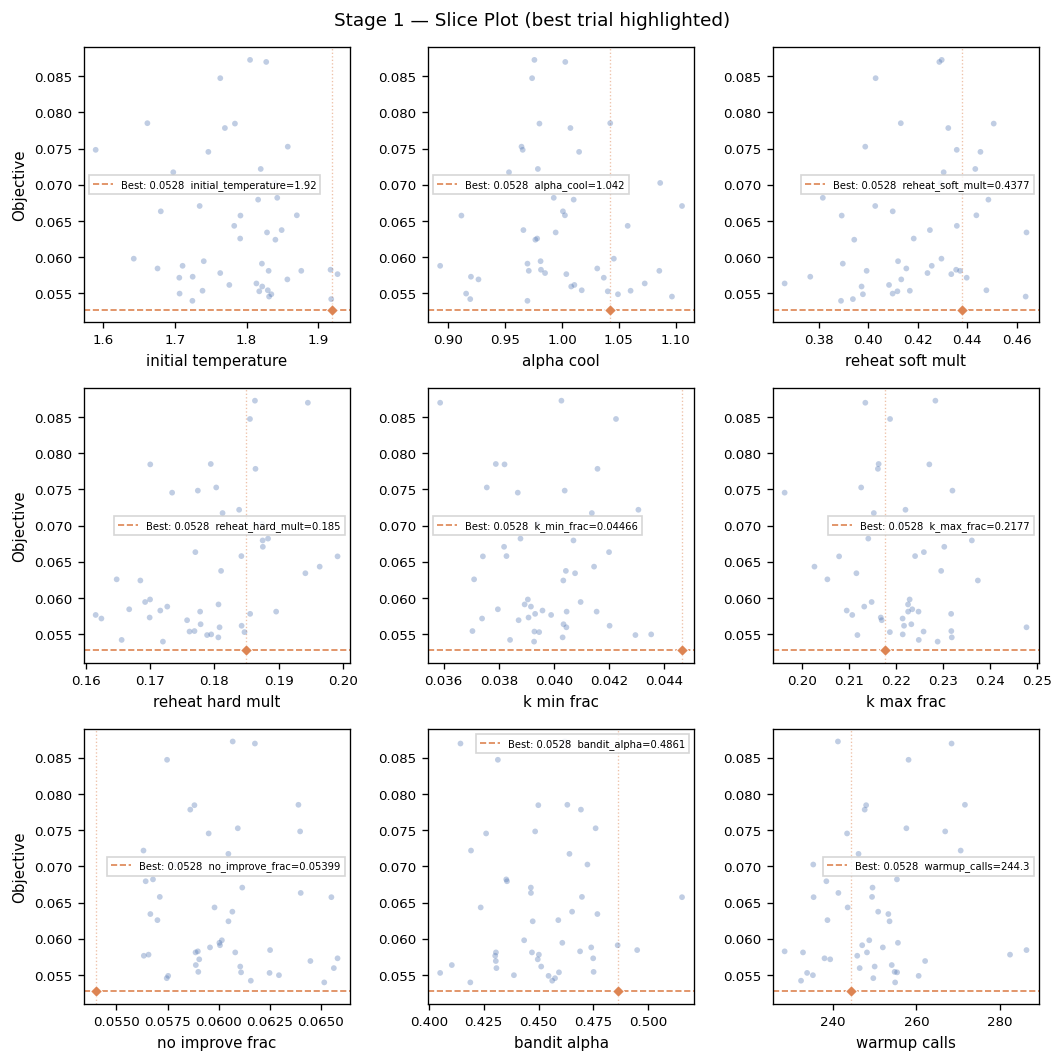

In [10]:
if stage1_raw:
    param_keys = list(stage1_raw["trials"][0]["params"].keys())
    best_trial = min(stage1_raw["trials"], key=lambda t: t["value"])
    best_metrics = best_trial.get("metrics", {})
    best_time = best_metrics.get("mean_time_s", None)

    n_cols = 3
    n_rows = (len(param_keys) + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(9, 3 * n_rows))
    axes = axes.flatten()

    for idx, pk in enumerate(param_keys):
        ax = axes[idx]
        vals_pk = [t["params"][pk] for t in stage1_raw["trials"]]
        obj = [t["value"] for t in stage1_raw["trials"]]

        ax.scatter(vals_pk, obj, s=12, c="#4C72B0", alpha=0.35, edgecolors="none", zorder=2)

        best_pk = best_trial["params"][pk]
        best_pk_str = f"{best_pk:.4g}" if isinstance(best_pk, float) else str(best_pk)
        time_str = f"{best_time:.1f}s" if best_time else f"{best_trial['value']:.4f}"
        label = f"Best: {time_str}  {pk}={best_pk_str}"

        ax.scatter(best_pk, best_trial["value"], s=25, c="#DD8452", edgecolors="white",
                   linewidth=0.6, zorder=4, marker="D")

        best_obj = min(obj)
        ax.axhline(best_obj, color="#DD8452", ls="--", lw=1, label=label, zorder=1)
        ax.axvline(best_pk, color="#DD8452", ls=":", lw=0.8, alpha=0.5, zorder=1)

        ax.set_xlabel(pk.replace("_", " "), fontsize=9)
        if idx % n_cols == 0:
            ax.set_ylabel("Objective", fontsize=9)
        ax.tick_params(labelsize=8)
        ax.legend(fontsize=6, frameon=True, fancybox=False)

    for j in range(idx + 1, len(axes)):
        axes[j].set_visible(False)

    fig.suptitle("Stage 1 — Slice Plot (best trial highlighted)", fontsize=11)
    fig.tight_layout()
    plt.show()


---
## 4. Stage 2 — Fine Search



In [11]:
if stage2_raw:
    print(f"Trials completed:       {stage2_raw['n_trials']}")
    print(f"Best composite objective: {stage2_raw['best_value']:.4f}")
    best_trial_s2 = min(stage2_raw["trials"], key=lambda t: t["value"])
    s2_mean_gap = best_trial_s2.get("metrics", {}).get("mean_relative_gap", stage2_raw["best_value"])

    print(f"Best parameters:")
    for k, v in stage2_raw["best_params"].items():
        print(f"    {k:25s} = {v}")

    def _all_trial_ranges(trials, margin=0.15):
        ranges = {}
        for pk in trials[0]["params"]:
            vals = [t["params"][pk] for t in trials]
            lo, hi = min(vals), max(vals)
            span = max(hi - lo, abs(lo) * 0.1)
            is_int = all(isinstance(v, int) for v in vals)
            if is_int:
                ranges[pk] = optuna.distributions.IntDistribution(
                    int(lo - span * margin), int(hi + span * margin + 1)
                )
            else:
                ranges[pk] = optuna.distributions.FloatDistribution(
                    lo - span * margin, hi + span * margin
                )
        return ranges

    stage2_study = optuna.create_study(
        direction="minimize", study_name=STAGE2_STUDY_NAME
    )
    dists = _all_trial_ranges(stage2_raw["trials"])
    for t in stage2_raw["trials"]:
        stage2_study.add_trial(
            optuna.trial.create_trial(
                params=t["params"],
                values=[t["value"]],
                distributions=dists,
                state=optuna.trial.TrialState.COMPLETE,
            )
        )


[I 2026-05-30 17:51:42,651] A new study created in memory with name: alns_stage2_fine


Trials completed:       50
Best composite objective: 0.0418
Best parameters:
    initial_temperature       = 1.65
    alpha_cool                = 0.99935
    reheat_soft_mult          = 0.38
    reheat_hard_mult          = 0.17
    k_min_frac                = 0.035
    k_max_frac                = 0.2
    no_improve_frac           = 0.045
    bandit_alpha              = 0.42
    warmup_calls              = 280


### 4.1 Convergence


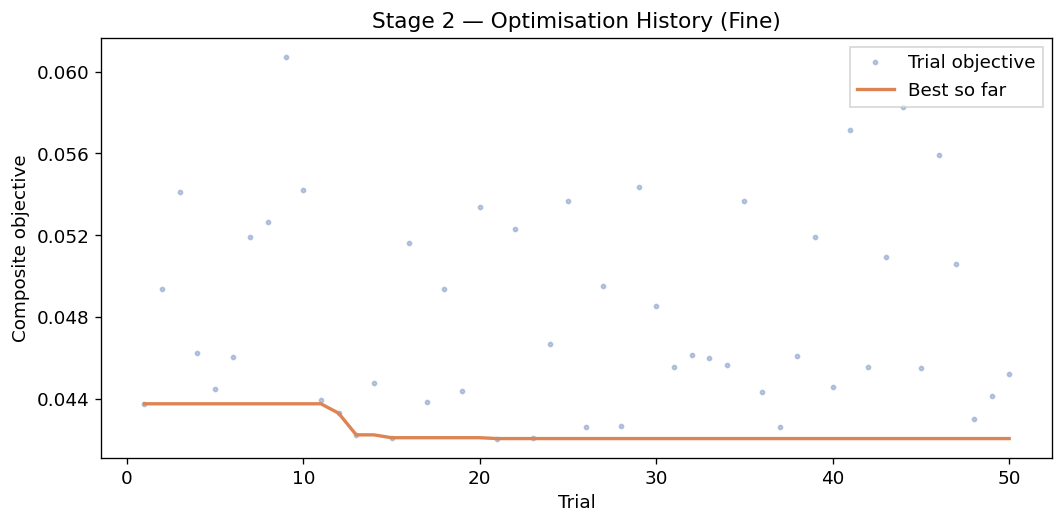

In [12]:
if stage2_raw:
    values = [t["value"] for t in stage2_raw["trials"]]
    best_so_far = np.minimum.accumulate(values)

    fig, ax = plt.subplots(figsize=(9, 4.5))
    ax.plot(range(1, len(values) + 1), values, "o", color="#4C72B0",
            markersize=2.5, alpha=0.35, label="Trial objective")
    ax.plot(range(1, len(values) + 1), best_so_far, "-", color="#DD8452",
            linewidth=2, label="Best so far")
    ax.set_xlabel("Trial")
    ax.set_ylabel("Composite objective")
    ax.set_title("Stage 2 — Optimisation History (Fine)")
    ax.legend(frameon=True, fancybox=False)
    ax.yaxis.set_major_locator(mticker.MaxNLocator(6))
    fig.tight_layout()
    plt.show()




### 4.2 Parameter Importance


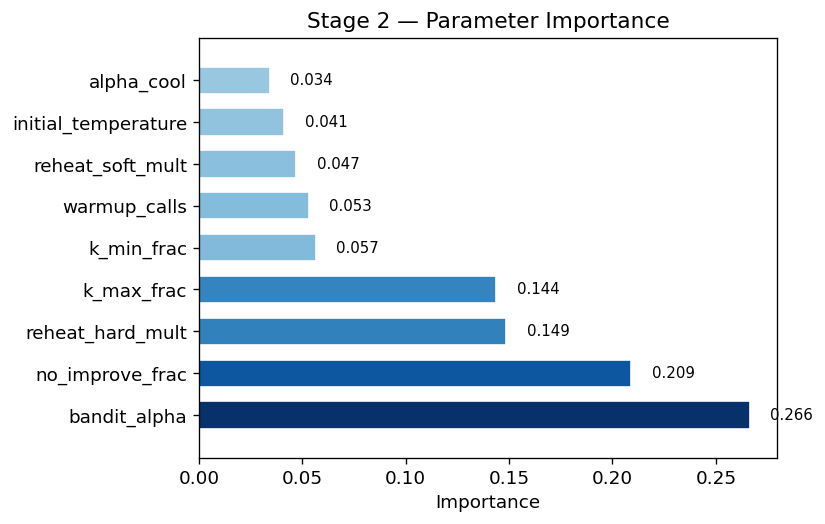

In [13]:
if stage2_raw:
    importances = get_param_importances(stage2_study)
    if not importances:
        print("Parameter importance: not available (insufficient trial variation).")
    else:
        params = list(importances.keys())
        scores = list(importances.values())
        score_arr = np.array(scores)
        colors = plt.cm.Blues(0.3 + 0.7 * (score_arr / score_arr.max()))

        fig, ax = plt.subplots(figsize=(7, 4.5))
        bars = ax.barh(params, scores, color=colors, edgecolor="white", height=0.65)
        for bar, s in zip(bars, scores):
            ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2,
                    f"{s:.3f}", va="center", fontsize=9)
        ax.set_xlabel("Importance")
        ax.set_title("Stage 2 — Parameter Importance")
        ax.margins(y=0.08)
        fig.tight_layout()
        plt.show()




### 4.3 Parameter Scatter


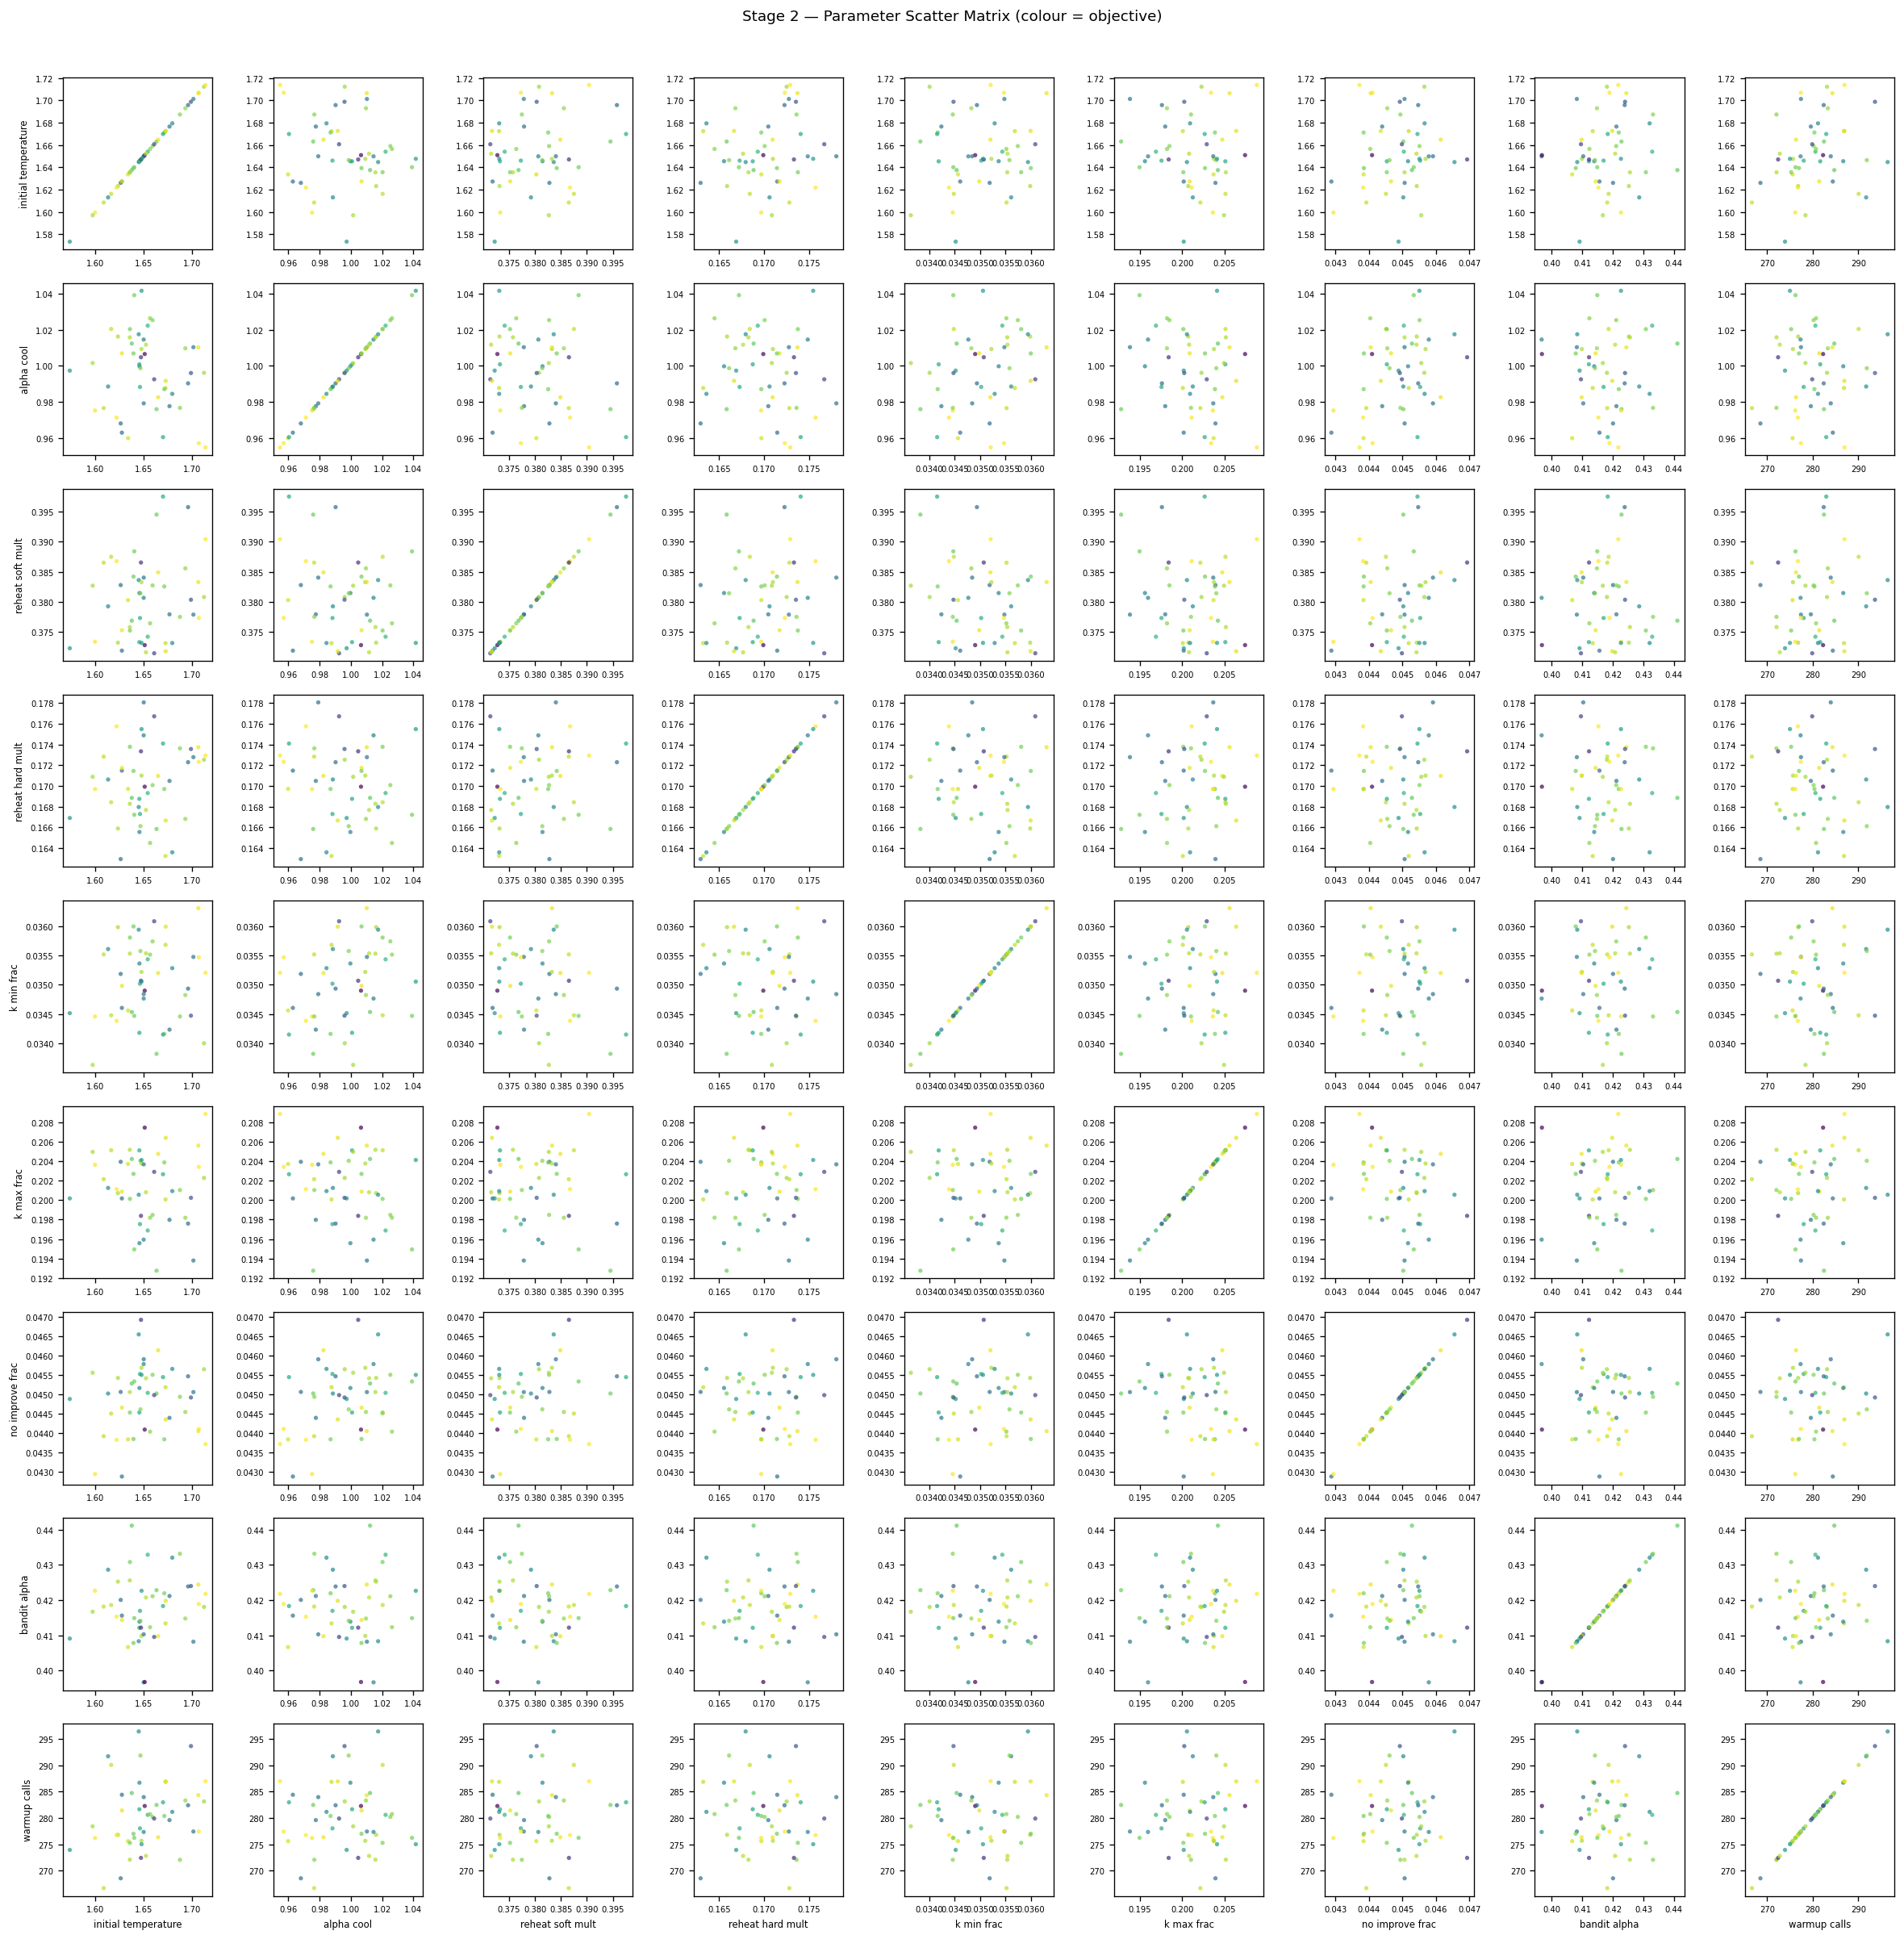

In [14]:
if stage2_raw and len(stage2_raw["trials"]) >= 5:
    param_keys = list(stage2_raw["trials"][0]["params"].keys())
    n = len(param_keys)
    fig, axes = plt.subplots(n, n, figsize=(2.2 * n, 2.2 * n))

    for i, pi in enumerate(param_keys):
        for j, pj in enumerate(param_keys):
            ax = axes[i, j]
            vals_i = [t["params"][pi] for t in stage2_raw["trials"]]
            vals_j = [t["params"][pj] for t in stage2_raw["trials"]]
            obj = [t["value"] for t in stage2_raw["trials"]]
            ax.scatter(vals_j, vals_i, c=obj, cmap="viridis_r",
                       s=10, alpha=0.7, edgecolors="none")
            if i == n - 1:
                ax.set_xlabel(pj.replace("_", " "), fontsize=7)
            if j == 0:
                ax.set_ylabel(pi.replace("_", " "), fontsize=7)
            ax.tick_params(labelsize=6)

    fig.suptitle("Stage 2 — Parameter Scatter Matrix (colour = objective)",
                 fontsize=11, y=1.01)
    fig.tight_layout()
    plt.show()


### 4.4 Slice Plot


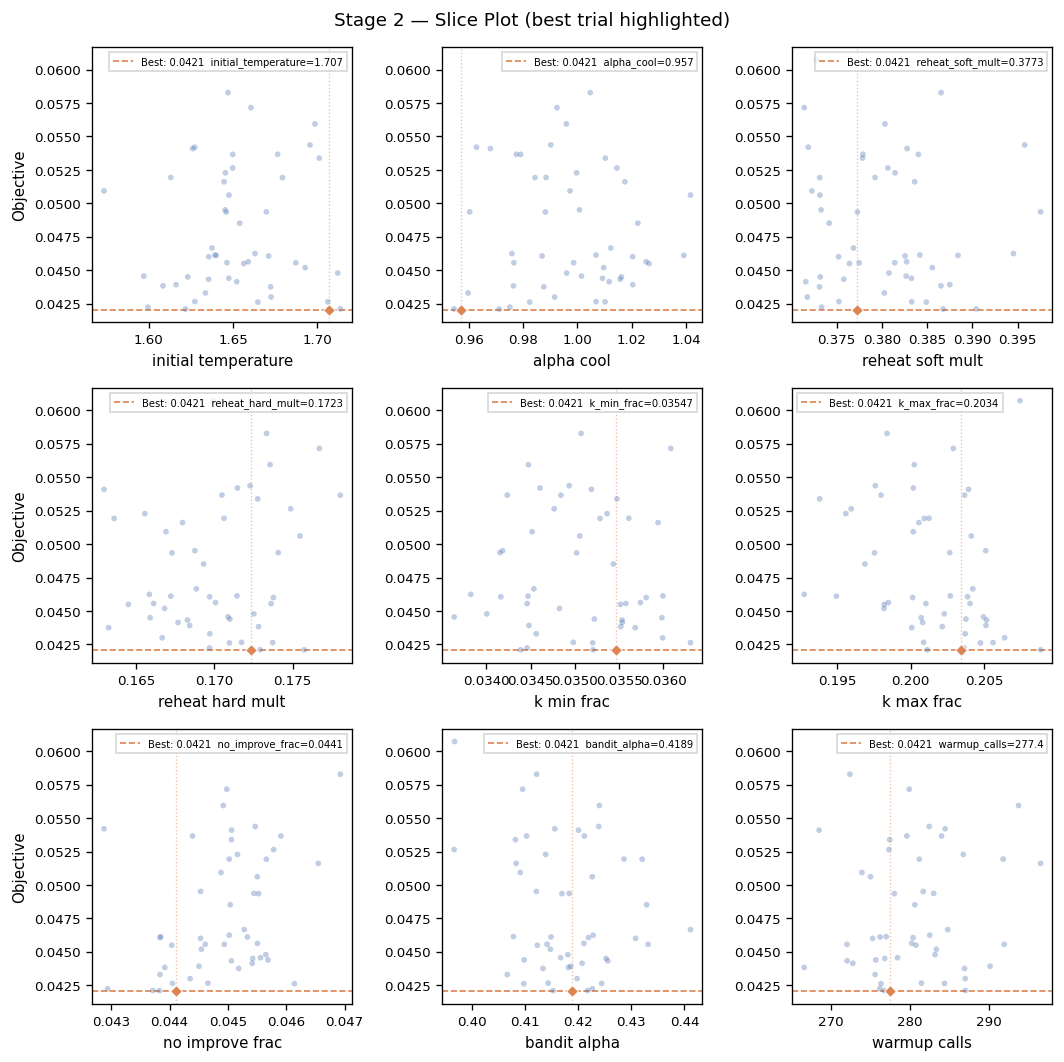

In [15]:
if stage2_raw:
    param_keys = list(stage2_raw["trials"][0]["params"].keys())
    best_trial = min(stage2_raw["trials"], key=lambda t: t["value"])
    best_metrics = best_trial.get("metrics", {})
    best_time = best_metrics.get("mean_time_s", None)

    n_cols = 3
    n_rows = (len(param_keys) + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(9, 3 * n_rows))
    axes = axes.flatten()

    for idx, pk in enumerate(param_keys):
        ax = axes[idx]
        vals_pk = [t["params"][pk] for t in stage2_raw["trials"]]
        obj = [t["value"] for t in stage2_raw["trials"]]

        ax.scatter(vals_pk, obj, s=12, c="#4C72B0", alpha=0.35, edgecolors="none", zorder=2)

        best_pk = best_trial["params"][pk]
        best_pk_str = f"{best_pk:.4g}" if isinstance(best_pk, float) else str(best_pk)
        time_str = f"{best_time:.1f}s" if best_time else f"{best_trial['value']:.4f}"
        label = f"Best: {time_str}  {pk}={best_pk_str}"

        ax.scatter(best_pk, best_trial["value"], s=25, c="#DD8452", edgecolors="white",
                   linewidth=0.6, zorder=4, marker="D")

        best_obj = min(obj)
        ax.axhline(best_obj, color="#DD8452", ls="--", lw=1, label=label, zorder=1)
        ax.axvline(best_pk, color="#DD8452", ls=":", lw=0.8, alpha=0.5, zorder=1)

        ax.set_xlabel(pk.replace("_", " "), fontsize=9)
        if idx % n_cols == 0:
            ax.set_ylabel("Objective", fontsize=9)
        ax.tick_params(labelsize=8)
        ax.legend(fontsize=6, frameon=True, fancybox=False)

    for j in range(idx + 1, len(axes)):
        axes[j].set_visible(False)

    fig.suptitle("Stage 2 — Slice Plot (best trial highlighted)", fontsize=11)
    fig.tight_layout()
    plt.show()


### 4.5 Convergence: Stage 1 vs Stage 2


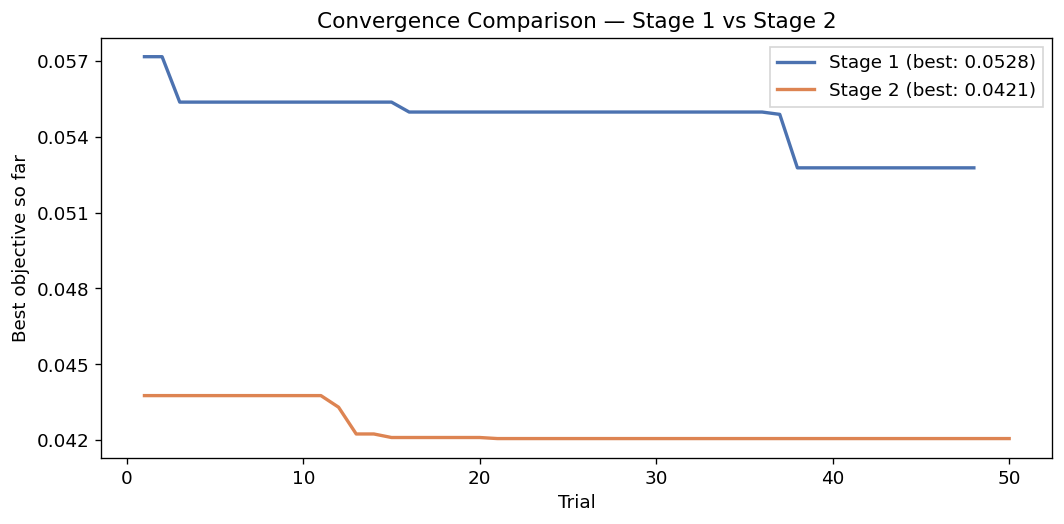

In [16]:
if stage1_raw and stage2_raw:
    fig, ax = plt.subplots(figsize=(9, 4.5))

    s1_vals = [t["value"] for t in stage1_raw["trials"]]
    s1_best = np.minimum.accumulate(s1_vals)
    s2_vals = [t["value"] for t in stage2_raw["trials"]]
    s2_best = np.minimum.accumulate(s2_vals)

    ax.plot(range(1, len(s1_vals) + 1), s1_best, "-", color="#4C72B0",
            linewidth=2, label=f"Stage 1 (best: {s1_best[-1]:.4f})")
    ax.plot(range(1, len(s2_vals) + 1), s2_best, "-", color="#DD8452",
            linewidth=2, label=f"Stage 2 (best: {s2_best[-1]:.4f})")

    ax.set_xlabel("Trial")
    ax.set_ylabel("Best objective so far")
    ax.set_title("Convergence Comparison — Stage 1 vs Stage 2")
    ax.legend(frameon=True, fancybox=False)
    ax.yaxis.set_major_locator(mticker.MaxNLocator(6))
    fig.tight_layout()
    plt.show()


---
## 5. Head-to-Head: Baseline vs Best



In [17]:
if data_loaded:
    b = baseline_raw["metrics"]
    r = best_raw["metrics"]

    rows = []
    for k in sorted(
        set(list(b["per_dataset_relative_gap"].keys()) + list(r["per_dataset_relative_gap"].keys()))
    ):
        rows.append(
            {
                "Dataset": k,
                "Baseline gap": round(b["per_dataset_relative_gap"].get(k, 0), 4),
                "Best gap": round(r["per_dataset_relative_gap"].get(k, 0), 4),
            }
        )
    rows.append(
        {
            "Dataset": "**Overall**",
            "Baseline gap": round(b["mean_relative_gap"], 4),
            "Best gap": round(r["mean_relative_gap"], 4),
        }
    )
    df_compare = pd.DataFrame(rows)
    df_compare["Improvement"] = df_compare["Baseline gap"] - df_compare["Best gap"]
    df_compare["% change"] = (
        (
            df_compare["Improvement"]
            / df_compare["Baseline gap"].replace(0, np.nan)
            * 100
        )
        .round(1)
        .map(lambda x: f"{x:+.1f}%" if pd.notna(x) else "—")
    )

    display(
        df_compare.style.set_caption("Per-Dataset Gap Comparison (baseline: 2 000 iter, best: 5 000 iter)")
        .set_table_styles(
            [
                {
                    "selector": "caption",
                    "props": "font-size: 1.2em; font-weight: bold; margin-bottom: 6px;",
                },
                {"selector": "th", "props": "text-align: left;"},
            ]
        )
        .format(
            {"Baseline gap": "{:.4f}", "Best gap": "{:.4f}", "Improvement": "{:.4f}"}
        )
    )

,Dataset,Baseline gap,Best gap,Improvement,% change
0,falkenauer-t,0.0900,0.0500,0.0400,+44.4%
1,falkenauer-u,0.0700,0.0300,0.0400,+57.1%
2,scholl-1,0.0500,0.0200,0.0300,+60.0%
3,scholl-2,0.0800,0.0400,0.0400,+50.0%
4,scholl-3,0.0600,0.0200,0.0400,+66.7%
5,**Overall**,0.0823,0.0418,0.0405,+49.2%


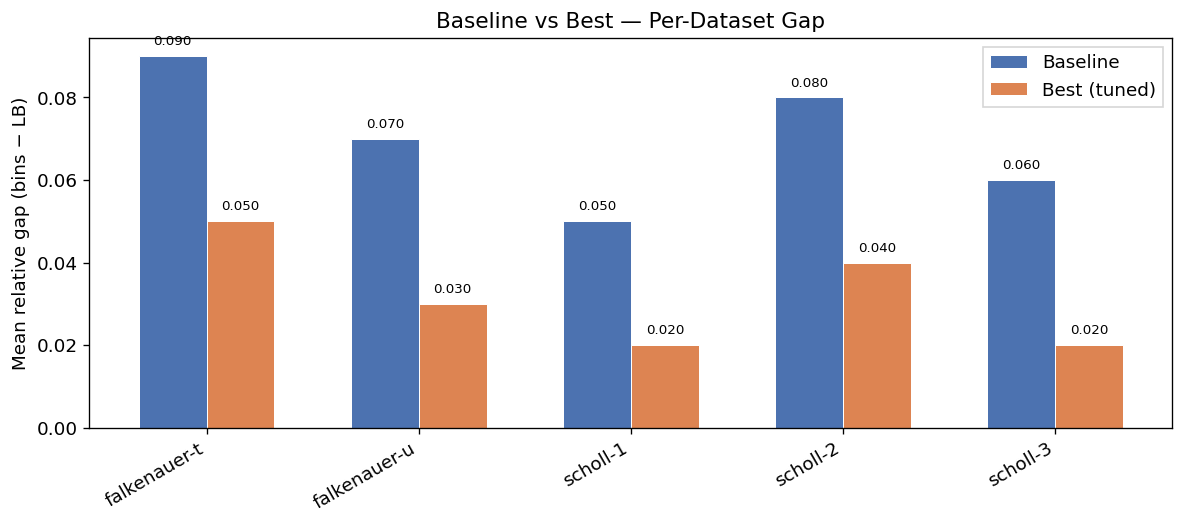

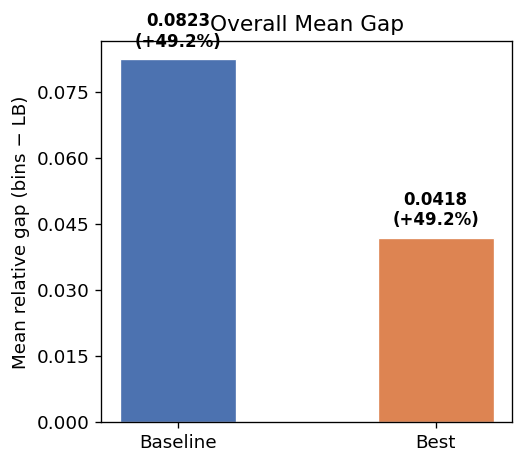

In [18]:
if data_loaded:
    labels = list(df_compare["Dataset"][:-1])
    x = np.arange(len(labels))
    width = 0.32

    fig, ax = plt.subplots(figsize=(10, 4.5))
    bars_b = ax.bar(x - width / 2, df_compare["Baseline gap"][:-1], width,
                    label="Baseline", color="#4C72B0", edgecolor="white", linewidth=0.6)
    bars_t = ax.bar(x + width / 2, df_compare["Best gap"][:-1], width,
                    label="Best (tuned)", color="#DD8452", edgecolor="white", linewidth=0.6)

    for bar in bars_b:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.002,
                f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=8)
    for bar in bars_t:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.002,
                f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=8)

    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=30, ha="right")
    ax.set_ylabel("Mean relative gap (bins \u2212 LB)")
    ax.set_title("Baseline vs Best \u2014 Per-Dataset Gap")
    ax.legend(frameon=True, fancybox=False)
    ax.yaxis.set_major_locator(mticker.MaxNLocator(6))
    fig.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(4.5, 4))
    cats = ["Baseline", "Best"]
    vals = [df_compare["Baseline gap"].iloc[-1], df_compare["Best gap"].iloc[-1]]
    colors_bar = ["#4C72B0", "#DD8452"]
    bars = ax.bar(cats, vals, color=colors_bar, edgecolor="white", width=0.45, linewidth=0.8)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.002,
                f"{v:.4f}\n({df_compare['% change'].iloc[-1]})",
                ha="center", va="bottom", fontweight="bold", fontsize=10)
    ax.set_ylabel("Mean relative gap (bins \u2212 LB)")
    ax.set_title("Overall Mean Gap")
    ax.yaxis.set_major_locator(mticker.MaxNLocator(6))
    fig.tight_layout()
    plt.show()


### 5.1 Gap Progression Through the Pipeline


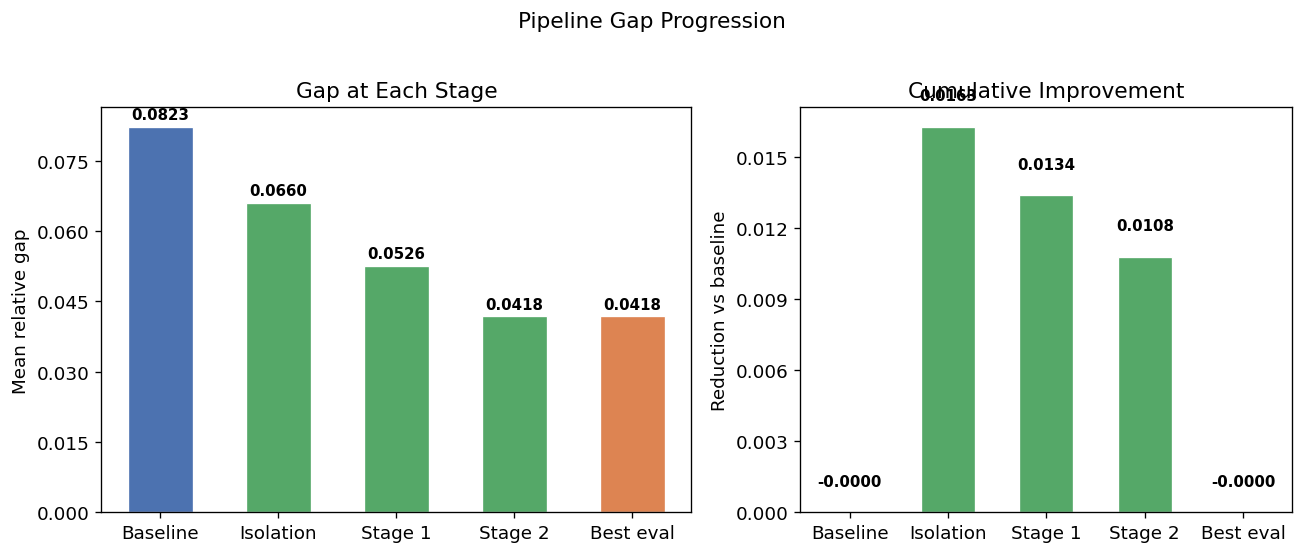

Total improvement: 0.0405  (49.2% reduction)


In [19]:
if data_loaded:
    stages_wf = ["Baseline"]
    gaps_wf = [baseline_raw["metrics"]["mean_relative_gap"]]

    if iso_merged_raw and "metrics" in iso_merged_raw:
        stages_wf.append("Isolation")
        gaps_wf.append(iso_merged_raw["metrics"]["mean_relative_gap"])

    if stage1_raw:
        stages_wf.append("Stage 1")
        s1_gap = best_trial_s1.get("metrics", {}).get("mean_relative_gap", None)
        if s1_gap is not None:
            gaps_wf.append(s1_gap)
        else:
            gaps_wf.append(stage1_raw["best_value"])

    if stage2_raw:
        stages_wf.append("Stage 2")
        s2_gap = best_trial_s2.get("metrics", {}).get("mean_relative_gap", None)
        if s2_gap is not None:
            gaps_wf.append(s2_gap)
        else:
            gaps_wf.append(stage2_raw["best_value"])

    stages_wf.append("Best eval")
    gaps_wf.append(best_raw["metrics"]["mean_relative_gap"])

    improvements = [gaps_wf[0] - g for g in gaps_wf]
    colors_wf = ["#4C72B0"] + ["#55A868"] * (len(stages_wf) - 2) + ["#DD8452"]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5),
                                    gridspec_kw={"width_ratios": [1.2, 1]})

    bars_gap = ax1.bar(stages_wf, gaps_wf, color=colors_wf, edgecolor="white",
                       width=0.55, linewidth=0.8)
    for bar, g in zip(bars_gap, gaps_wf):
        ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.001,
                 f"{g:.4f}", ha="center", va="bottom", fontsize=9, fontweight="bold")
    ax1.set_ylabel("Mean relative gap")
    ax1.set_title("Gap at Each Stage")
    ax1.yaxis.set_major_locator(mticker.MaxNLocator(6))

    cumul_improvement = np.diff([gaps_wf[0]] + gaps_wf)
    cumul_colors = ["#DD8452" if c < 0 else "#55A868" for c in cumul_improvement]
    bars_imp = ax2.bar(stages_wf, [-c for c in cumul_improvement],
                       color="#55A868", edgecolor="white", width=0.55, linewidth=0.8)
    for bar, imp in zip(bars_imp, [-c for c in cumul_improvement]):
        ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.001,
                 f"{imp:.4f}", ha="center", va="bottom", fontsize=9, fontweight="bold")
    ax2.set_ylabel("Reduction vs baseline")
    ax2.set_title("Cumulative Improvement")
    ax2.yaxis.set_major_locator(mticker.MaxNLocator(6))

    fig.suptitle("Pipeline Gap Progression", fontsize=13, y=1.02)
    fig.tight_layout()
    plt.show()

    total_improvement = gaps_wf[0] - gaps_wf[-1]
    total_pct = (total_improvement / gaps_wf[0]) * 100 if gaps_wf[0] > 0 else 0
    print(f"Total improvement: {total_improvement:.4f}  ({total_pct:.1f}% reduction)")


---
## 6. Arm-Pull Analysis



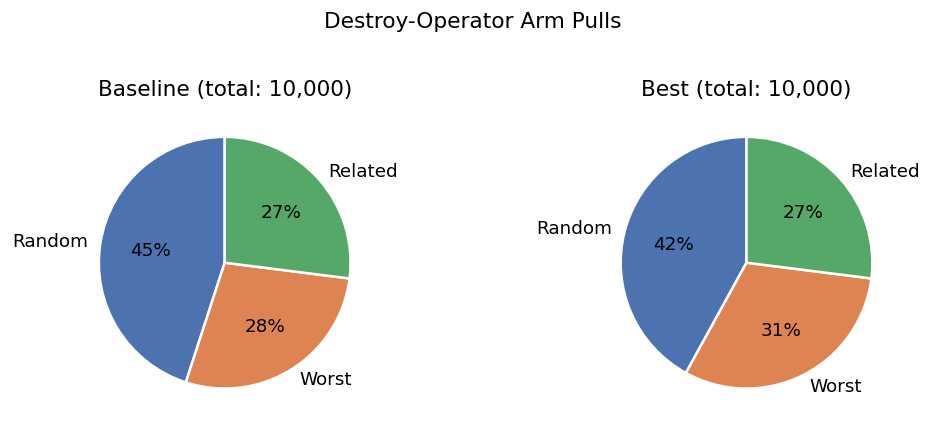

In [20]:
if data_loaded:
    fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))

    for ax, (label, data) in zip(
        axes,
        [
            ("Baseline", baseline_raw["metrics"]["arm_pulls"]),
            ("Best", best_raw["metrics"]["arm_pulls"]),
        ],
    ):
        total = sum(data)
        colors = ["#4C72B0", "#DD8452", "#55A868"]
        wedges, texts, autotexts = ax.pie(
            data,
            labels=["Random", "Worst", "Related"],
            autopct="%1.0f%%",
            colors=colors,
            startangle=90,
            wedgeprops=dict(edgecolor="white", linewidth=1.5),
        )
        ax.set_title(f"{label} (total: {total:,})")

    fig.suptitle("Destroy-Operator Arm Pulls", fontsize=13, y=1.02)
    fig.tight_layout()
    plt.show()

---
## 7. Timing Summary



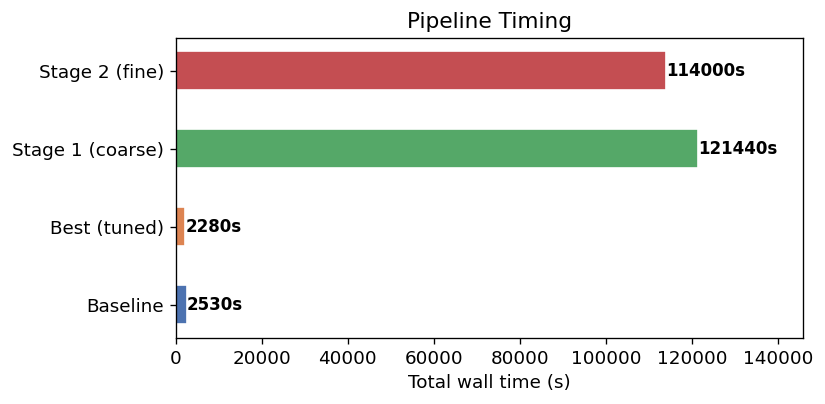

,Run,Mean / instance (s),Total (s)
0,Baseline,25.30,2530
1,Best (tuned),22.80,2280
2,Stage 1 (coarse),nan,121440
3,Stage 2 (fine),nan,114000


In [21]:
if data_loaded:
    timing_rows = [
        (
            "Baseline",
            baseline_raw["metrics"]["mean_time_s"],
            baseline_raw["metrics"]["total_time_s"],
        ),
        (
            "Best (tuned)",
            best_raw["metrics"]["mean_time_s"],
            best_raw["metrics"]["total_time_s"],
        ),
    ]
    if stage1_raw:
        timing_rows.append(
            (
                "Stage 1 (coarse)",
                None,
                stage1_raw["n_trials"] * baseline_raw["metrics"]["total_time_s"],
            )
        )
    if stage2_raw:
        timing_rows.append(
            (
                "Stage 2 (fine)",
                None,
                stage2_raw["n_trials"] * best_raw["metrics"]["total_time_s"],
            )
        )

    fig, ax = plt.subplots(figsize=(7, 3.5))
    run_labels = [r[0] for r in timing_rows]
    run_totals = [r[2] if r[2] else 0 for r in timing_rows]
    run_means = [r[1] if r[1] else 0 for r in timing_rows]
    colors_time = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"][:len(timing_rows)]
    bars = ax.barh(run_labels, run_totals, color=colors_time, edgecolor="white", height=0.5)
    for bar, t in zip(bars, run_totals):
        ax.text(bar.get_width() + 10, bar.get_y() + bar.get_height() / 2,
                f"{t:.0f}s", va="center", fontsize=10, fontweight="bold")
    ax.set_xlabel("Total wall time (s)")
    ax.set_title("Pipeline Timing")
    ax.margins(x=0.2)
    fig.tight_layout()
    plt.show()

    df_time = pd.DataFrame(
        timing_rows, columns=["Run", "Mean / instance (s)", "Total (s)"]
    )
    display(
        df_time.style.set_caption("Timing")
        .set_table_styles(
            [
                {
                    "selector": "caption",
                    "props": "font-size: 1.2em; font-weight: bold; margin-bottom: 6px;",
                },
                {"selector": "th", "props": "text-align: left;"},
            ]
        )
        .format({"Mean / instance (s)": "{:.2f}", "Total (s)": "{:.0f}"})
    )


---
## 8. Parameter Evolution



,default (initial),after isolation,after Stage 1,after Stage 2 (final)
initial_temperature,1.4427,1.2,1.8,1.65
alpha_cool,0.9995,0.9985,0.9992,0.99935
k_min_frac,0.05,0.03,0.04,0.035
k_max_frac,0.25,0.2,0.22,0.2
bandit_alpha,0.3,0.5,0.45,0.42
warmup_calls,300,200,250,280
no_improve_frac,0.05,0.04,0.06,0.045
reheat_soft_mult,0.35,0.3,0.42,0.38
reheat_hard_mult,0.2,0.15,0.18,0.17


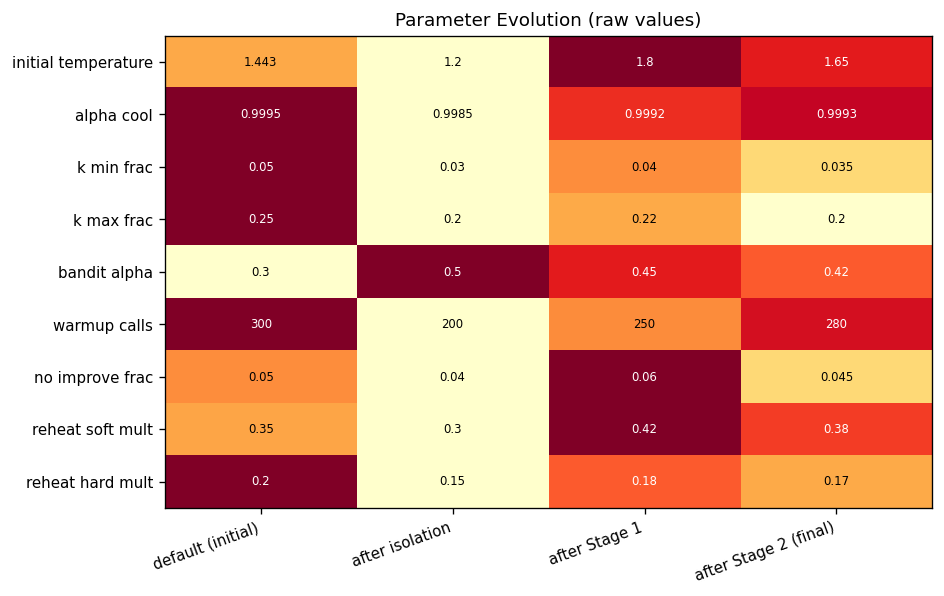

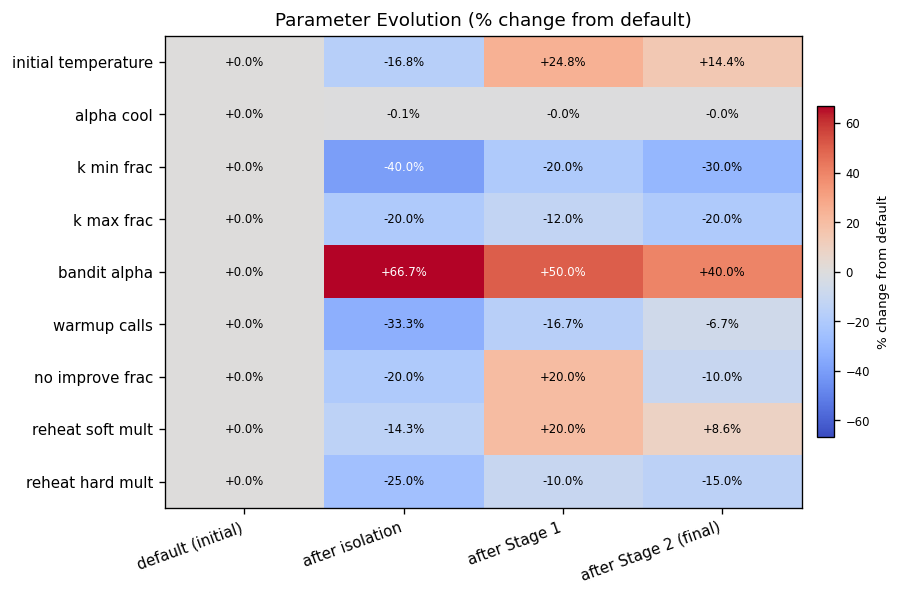


  Best configuration (full, with structural defaults)
    initial_temperature            = 1.65
    alpha_cool                     = 0.99935
    k_min_frac                     = 0.035
    k_max_frac                     = 0.2
    bandit_alpha                   = 0.42
    warmup_calls                   = 280
    no_improve_frac                = 0.045
    reheat_soft_mult               = 0.38
    reheat_hard_mult               = 0.17
    min_no_improve_limit           = 250
    temp_precision_floor           = 1e-12
    reheat_check_interval_divisor  = 4.0
    reheat_check_min_interval      = 50
    hard_restart_min_limit         = 100
    patience_shrink_factor         = 0.6666666666666666


In [22]:
if stage2_raw:
    # Build evolution table
    stages = {"default\n(initial)": dict(DEFAULT_PARAMS)}
    if iso_merged_raw:
        stages["after\nisolation"] = {**DEFAULT_PARAMS, **iso_merged_raw["parameters"]}
    if stage1_raw:
        stages["after\nStage 1"] = {**DEFAULT_PARAMS, **stage1_raw["best_params"]}
    stages["after\nStage 2\n(final)"] = {**DEFAULT_PARAMS, **stage2_raw["best_params"]}

    cols = ["Parameter"] + list(stages.keys())
    df_evo = pd.DataFrame(index=[p for p in DEFAULT_PARAMS])
    for label, cfg in stages.items():
        row = []
        for p in df_evo.index:
            v = cfg.get(p, "—")
            if isinstance(v, float):
                row.append(f"{v:.6g}")
            else:
                row.append(str(v))
        df_evo[label.replace(chr(10), " ")] = row

    display(
        df_evo.style.set_caption(
            "Parameter Evolution Through the Pipeline"
        ).set_table_styles(
            [
                {
                    "selector": "caption",
                    "props": "font-size: 1.2em; font-weight: bold; margin-bottom: 6px;",
                },
                {"selector": "th", "props": "text-align: left;"},
            ]
        )
    )

    # Full merged best (including structural)
    # Raw values heatmap (each row independently coloured to show direction)
    param_names = [p for p in DEFAULT_PARAMS]
    stage_labels = [s.replace(chr(10), " ") for s in stages.keys()]
    n_params, n_stages = len(param_names), len(stage_labels)

    raw_data = np.zeros((n_params, n_stages))
    for j, (label, cfg) in enumerate(stages.items()):
        for i, p in enumerate(param_names):
            v = cfg.get(p, None)
            raw_data[i, j] = v if isinstance(v, (int, float)) else 0

    raw_norm = np.zeros_like(raw_data)
    for i in range(n_params):
        r = raw_data[i]
        mn, mx = r.min(), r.max()
        raw_norm[i] = (r - mn) / (mx - mn + 1e-12)

    fig, ax = plt.subplots(figsize=(8, 0.4 * n_params + 1.5))
    im = ax.imshow(raw_norm, aspect="auto", cmap="YlOrRd", interpolation="nearest")

    ax.set_yticks(range(n_params))
    ax.set_yticklabels([p.replace("_", " ") for p in param_names], fontsize=9)
    ax.set_xticks(range(n_stages))
    ax.set_xticklabels(stage_labels, fontsize=9, rotation=20, ha="right")
    ax.set_title("Parameter Evolution (raw values)", fontsize=11)

    for i in range(n_params):
        for j in range(n_stages):
            v = raw_data[i, j]
            txt = f"{v:.4g}" if isinstance(v, float) else str(v)
            ax.text(j, i, txt, ha="center", va="center", fontsize=7,
                    color="white" if raw_norm[i, j] > 0.5 else "black")

    fig.tight_layout()
    plt.show()

    # Diverging heatmap: colour shows % change from default (red = increase, blue = decrease)
    param_names = [p for p in DEFAULT_PARAMS]
    stage_labels = [s.replace(chr(10), " ") for s in stages.keys()]

    defaults = dict(DEFAULT_PARAMS)
    n_params, n_stages = len(param_names), len(stage_labels)
    pct_change = np.full((n_params, n_stages), np.nan)

    for j, (label, cfg) in enumerate(stages.items()):
        for i, p in enumerate(param_names):
            v = cfg.get(p, None)
            d = defaults.get(p, None)
            if isinstance(v, (int, float)) and isinstance(d, (int, float)) and d != 0:
                pct_change[i, j] = (v - d) / abs(d) * 100
            elif isinstance(v, (int, float)):
                pct_change[i, j] = 0.0

    vlim = max(abs(pct_change[~np.isnan(pct_change)].min()),
               abs(pct_change[~np.isnan(pct_change)].max()), 1.0)

    fig, ax = plt.subplots(figsize=(8, 0.4 * n_params + 1.5))
    im = ax.imshow(pct_change, aspect="auto", cmap="coolwarm",
                   vmin=-vlim, vmax=vlim, interpolation="nearest")

    ax.set_yticks(range(n_params))
    ax.set_yticklabels([p.replace("_", " ") for p in param_names], fontsize=9)
    ax.set_xticks(range(n_stages))
    ax.set_xticklabels(stage_labels, fontsize=9, rotation=20, ha="right")
    ax.set_title("Parameter Evolution (% change from default)", fontsize=11)

    for i in range(n_params):
        for j in range(n_stages):
            v = pct_change[i, j]
            if np.isnan(v):
                continue
            text_color = "white" if abs(v) > vlim * 0.6 else "black"
            ax.text(j, i, f"{v:+.1f}%", ha="center", va="center",
                    fontsize=7, color=text_color)

    cbar = fig.colorbar(im, ax=ax, shrink=0.7, pad=0.02)
    cbar.set_label("% change from default", fontsize=8)
    cbar.ax.tick_params(labelsize=7)

    fig.tight_layout()
    plt.show()
    print("\n" + "=" * 50)
    print("  Best configuration (full, with structural defaults)")
    print("=" * 50)
    best = {**DEFAULT_PARAMS, **STRUCTURAL_DEFAULTS, **stage2_raw["best_params"]}
    for k, v in best.items():
        print(f"    {k:30s} = {v}")




---
## 9. Summary

- 3-stage pipeline: **Isolation grid search → Stage 1 (coarse Optuna) → Stage 2 (fine Optuna)**
- **9 tunable** parameters + **6 structural** held fixed
- **100-instance bank** stratified by item-count across 5 datasets
- Objective: **90% gap + 10% time**
- See `tuning_approach.ipynb` for the complete methodology.
